In [1]:
!pip -q install transformers accelerate lpips torchmetrics[image] scikit-image scipy pandas pyarrow kornia

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_AVAILABLE = True
    print("Drive mounted.")
except Exception:
    DRIVE_AVAILABLE = False
    print("Drive not mounted.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.6 MB/s eta 0:00:00
Mounted at /content/drive
Drive mounted.


In [ ]:
import shutil, os, glob, zipfile

# ── Copy results from Drive to session storage ──
DRIVE_RESULTS = "/content/drive/MyDrive/results"
RESULTS_DIR   = "/content/results"

if os.path.isdir(DRIVE_RESULTS):
    if os.path.exists(RESULTS_DIR):
        shutil.rmtree(RESULTS_DIR)
    shutil.copytree(DRIVE_RESULTS, RESULTS_DIR)
    n_files = sum(len(f) for _, _, f in os.walk(RESULTS_DIR))
    print(f"Copied {DRIVE_RESULTS} -> {RESULTS_DIR} ({n_files} files)")
elif os.path.isdir(RESULTS_DIR):
    print(f"Using existing {RESULTS_DIR}")
else:
    raise FileNotFoundError(f"No results folder found at {DRIVE_RESULTS} or {RESULTS_DIR}")

# ── Download COCO dataset ──
N_IMAGES   = -1
KAGGLE_DS  = "abdelrahmanelgharibx/coco2017-subset"
LOCAL_DIR  = "/content/coco_local"

if os.path.isdir(LOCAL_DIR) and len(os.listdir(LOCAL_DIR)) > 0:
    print("Dataset already present, skipping download.")
else:
    import kagglehub
    dl_path = kagglehub.dataset_download(KAGGLE_DS)
    print(f"Downloaded to: {dl_path}")
    os.makedirs(LOCAL_DIR, exist_ok=True)
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    for zf in glob.glob(os.path.join(dl_path, "**", "*.zip"), recursive=True):
        print(f"Extracting {zf}...")
        with zipfile.ZipFile(zf) as z:
            z.extractall(dl_path)
    count = 0
    for root, _, files in os.walk(dl_path):
        for fn in files:
            if os.path.splitext(fn)[1].lower() in IMG_EXTS:
                src = os.path.join(root, fn)
                dst = os.path.join(LOCAL_DIR, fn)
                if not os.path.exists(dst):
                    os.link(src, dst) if os.stat(src).st_dev == os.stat(LOCAL_DIR).st_dev else __import__('shutil').copy2(src, dst)
                    count += 1
    print(f"Moved {count} images into {LOCAL_DIR}")

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
all_files = sorted([f for f in os.listdir(LOCAL_DIR) if os.path.splitext(f)[1].lower() in IMG_EXTS])
print(f"Total images: {len(all_files)}")
if N_IMAGES > 0 and N_IMAGES < len(all_files):
    all_files = all_files[-N_IMAGES:]
IMAGES_DIR = LOCAL_DIR
print(f"Dataset ready -- {len(all_files)} images in {IMAGES_DIR}")


Copied /content/drive/MyDrive/results -> /content/results (45 files)


100%|██████████| 11.7G/11.7G [04:56<00:00, 42.5MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/abdelrahmanelgharibx/coco2017-subset/versions/1
Moved 76079 images into /content/coco_local
Total images: 76079
Dataset ready -- 76079 images in /content/coco_local


In [ ]:
import os,random,math,warnings,json,glob,copy,csv,time,re
import numpy as np,pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms; from PIL import Image
from tqdm.auto import tqdm; from skimage import color as skcolor
from skimage.color import deltaE_ciede2000
import lpips
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image import PeakSignalNoiseRatio,StructuralSimilarityIndexMeasure
from transformers import BlipProcessor,BlipForConditionalGeneration
from transformers import CLIPTokenizer,CLIPTextModel

def seed_all(s=42):
    random.seed(s);np.random.seed(s);torch.manual_seed(s);torch.cuda.manual_seed_all(s)

# ── Paths ──
RESULTS_DIR = "/content/results"
OUT_DIR = "/content/visuals"
os.makedirs(OUT_DIR, exist_ok=True)

CONFIG={
 "n_images":N_IMAGES,
 "images_dir":IMAGES_DIR,
 "train_ratio":0.70,"val_ratio":0.15,"test_ratio":0.15,"seed":42,
 "img_size":256,"batch_size":16,
 "mdn_K":5,"mdn_min_sigma":1e-3,"mdn_log_sigma_min":-7.0,"mdn_log_sigma_max":3.0,
 "use_text":True,"text_dim":512,"max_text_tokens":20,
 "caption_max_new_tokens":20,
 "caption_model":"Salesforce/blip-image-captioning-base",
 "clip_text_model":"openai/clip-vit-base-patch32",
 "text_mode":"token_attn",
 "cache_text":False,
 "cache_dir":"/content/colorization_cache",
 "save_dir":OUT_DIR,
 "device":"cuda" if torch.cuda.is_available() else "cpu",
 "num_workers":0,"eval_max_batches":50,
 "mdn_temperatures":[0.5,0.8,1.0,1.5],"mdn_best_of_n":5,
}
os.makedirs(CONFIG["cache_dir"],exist_ok=True)
seed_all(CONFIG["seed"])

# ── Compact matplotlib style ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.3,
    'lines.linewidth': 1.0,
})

print(f"Device: {CONFIG['device']}")
print(f"Results from: {RESULTS_DIR}")
print(f"Outputs to:   {OUT_DIR}")


Device: cuda
Results from: /content/results
Outputs to:   /content/visuals


In [ ]:
images_dir=CONFIG['images_dir']
IMG_EXTS={'.jpg','.jpeg','.png','.bmp','.tiff','.webp'}
image_paths=sorted([
    os.path.join(images_dir,f) for f in os.listdir(images_dir)
    if os.path.splitext(f)[1].lower() in IMG_EXTS
])
assert len(image_paths)>0
if CONFIG["n_images"]>0 and CONFIG["n_images"]<len(image_paths):
    image_paths=image_paths[-CONFIG["n_images"]:]
    print(f"Using last {len(image_paths)} of available images")

# Reproduce the EXACT same split used during training
seed_all(CONFIG["seed"])
idx=list(range(len(image_paths)));random.shuffle(idx)
n=len(idx);nt=int(n*CONFIG["train_ratio"]);nv=int(n*CONFIG["val_ratio"])
train_idx,val_idx,test_idx=sorted(idx[:nt]),sorted(idx[nt:nt+nv]),sorted(idx[nt+nv:])
train_paths=[image_paths[i] for i in train_idx]
val_paths=[image_paths[i] for i in val_idx]
test_paths=[image_paths[i] for i in test_idx]
print(f"Train:{len(train_paths)} Val:{len(val_paths)} Test:{len(test_paths)}")

S=CONFIG["img_size"]
tfm_e=transforms.Compose([transforms.Resize((S,S))])
class CDS(Dataset):
    def __init__(s,p,t): s.p,s.t=p,t
    def __len__(s): return len(s.p)
    def __getitem__(s,i):
        img=s.t(Image.open(s.p[i]).convert("RGB"))
        rgb=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb)
        L=torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float()
        ab=torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float()
        return L,ab,torch.from_numpy(rgb).permute(2,0,1).float(),i
train_ds=CDS(train_paths,tfm_e)
val_ds=CDS(val_paths,tfm_e)
test_ds=CDS(test_paths,tfm_e)
test_loader=DataLoader(test_ds,CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=True)
print(f"Test dataset: {len(test_ds)} images")


Train:53255 Val:11411 Test:11413
Test dataset: 11413 images


In [ ]:
def to_uint8(x): return (x.clamp(0,1)*255).to(torch.uint8)

def lab_to_rgb_diff(L,ab):
    Ls=L*100;a,b=ab[:,0:1]*128,ab[:,1:2]*128
    fy=(Ls+16)/116;fx=a/500+fy;fz=fy-b/200;d=6/29
    def fi(t): return torch.where(t>d,t**3,3*d**2*(t-4/29))
    X,Y,Z=0.950456*fi(fx),fi(fy),1.088754*fi(fz)
    R,G,B=3.2404542*X-1.5371385*Y-0.4985314*Z,-0.969266*X+1.876011*Y+0.041556*Z,0.055643*X-0.204026*Y+1.057225*Z
    def sr(c): return torch.where(c>0.0031308,1.055*c.clamp(min=1e-8).pow(1/2.4)-0.055,12.92*c)
    return torch.cat([sr(R),sr(G),sr(B)],1).clamp(0,1)

def lab_to_rgb_np(L,ab):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Ln=(L.detach().cpu().numpy().transpose(0,2,3,1)*100).astype(np.float32)
        An=(ab.detach().cpu().numpy().transpose(0,2,3,1)*128).astype(np.float32)
        o=[np.clip(skcolor.lab2rgb(np.concatenate([Ln[i],An[i]],-1)),0,1) for i in range(Ln.shape[0])]
    return torch.from_numpy(np.stack(o)).permute(0,3,1,2).float().to(L.device)

def ciede2000_batch(Lg,ag,ap):
    Ln=(Lg.detach().cpu().numpy().transpose(0,2,3,1)*100)
    A1=(ag.detach().cpu().numpy().transpose(0,2,3,1)*128);A2=(ap.detach().cpu().numpy().transpose(0,2,3,1)*128)
    return float(np.mean([deltaE_ciede2000(np.concatenate([Ln[i],A1[i]],-1),np.concatenate([Ln[i],A2[i]],-1)).mean() for i in range(Ln.shape[0])]))

def mdn_nll(pi,mu,ls,t,ms=1e-3):
    B,K,H,W=pi.shape;x=t.unsqueeze(1).expand(-1,K,-1,-1,-1)
    ls=ls.clamp(CONFIG["mdn_log_sigma_min"],CONFIG["mdn_log_sigma_max"])
    s=torch.exp(ls).clamp(min=ms)
    lp=-0.5*(((x-mu)/s)**2+2*torch.log(s)+math.log(2*math.pi))
    return -torch.logsumexp(torch.log_softmax(pi,1)+lp.sum(2),1).mean()

@torch.no_grad()
def mdn_expected_ab(pi,mu):
    return (torch.softmax(pi,1).unsqueeze(2)*mu).sum(1)

@torch.no_grad()
def mdn_map_ab(pi,mu):
    k=torch.softmax(pi,1).argmax(1,keepdim=True).unsqueeze(2).expand(-1,-1,2,-1,-1)
    return mu.gather(1,k).squeeze(1)

@torch.no_grad()
def mdn_sample_ab(pi,mu,log_sigma,temperature=1.0):
    w=torch.softmax(pi/temperature,1)
    B,K,_,H,W=mu.shape
    idx=torch.multinomial(w.permute(0,2,3,1).reshape(-1,K),1).view(B,H,W,1,1).permute(0,3,4,1,2).expand(-1,-1,2,-1,-1)
    m=mu.gather(1,idx).squeeze(1);ls=log_sigma.gather(1,idx).squeeze(1)
    return m+torch.randn_like(m)*torch.exp(ls).clamp(min=CONFIG["mdn_min_sigma"])*temperature

@torch.no_grad()
def mdn_best_of_n(pi,mu,log_sigma,L,ab_gt,n=5):
    best=None;best_l1=float('inf')
    for _ in range(n):
        s=mdn_sample_ab(pi,mu,log_sigma,1.0)
        l1=F.l1_loss(s,ab_gt).item()
        if l1<best_l1: best_l1=l1;best=s
    return best

def chroma_diagnostics(ab_gt,ab_pred):
    gt=(ab_gt.detach().cpu().numpy().transpose(0,2,3,1)*128)
    pr=(ab_pred.detach().cpu().numpy().transpose(0,2,3,1)*128)
    c_gt=np.sqrt(gt[...,0]**2+gt[...,1]**2).ravel()
    c_pr=np.sqrt(pr[...,0]**2+pr[...,1]**2).ravel()
    return {"a_gt":gt[...,0].ravel(),"b_gt":gt[...,1].ravel(),
            "a_pr":pr[...,0].ravel(),"b_pr":pr[...,1].ravel(),
            "chroma_gt":c_gt,"chroma_pr":c_pr,
            "chroma_ratio":np.mean(c_pr)/max(np.mean(c_gt),1e-6)}

def chroma_loss(ab_pred, ab_gt):
    C_pred = torch.sqrt(ab_pred[:,0:1]**2 + ab_pred[:,1:2]**2 + 1e-8)
    C_gt   = torch.sqrt(ab_gt[:,0:1]**2 + ab_gt[:,1:2]**2 + 1e-8)
    return F.l1_loss(C_pred, C_gt)

print("Utilities ready")


Utilities ready


In [ ]:
_STOP=set(("a an the of in on at to and with is are was were that this for it its by from "
"as or be been being do does did has have had will would shall should may might can could "
"not no nor so if but very much more most also just only even still already yet than "
"some any all each every both few many several own other another such "
"here there where when how what which who whom whose why "
"black white photo photograph image picture view shown camera shot scene background "
"foreground side front back top bottom left right center middle large small big little "
"old new first last next long short high low good bad great real close open going sitting "
"standing looking wearing holding playing walking running making taking getting using "
"two three four five group pair set lot number kind type part piece bit way thing "
"day room area place point end line made seen "
"between above below behind along across through around near "
"young different same full empty various about away down into "
"eating flying lying parked covered filled moving turned during").split())

def caption_to_tags(caption):
    words=re.findall(r'[a-z]+',caption.lower())
    return ", ".join([w for w in words if w not in _STOP and len(w)>2][:8]) or caption

@torch.no_grad()
def build_text_cache(paths,split_name,device):
    cache_path=os.path.join(CONFIG["cache_dir"],f"{split_name}_text_tokens.pt")
    if CONFIG["cache_text"] and os.path.exists(cache_path):
        print(f"Loading cached text: {cache_path}")
        return torch.load(cache_path,map_location="cpu"),[]
    print(f"Computing text embeddings for {split_name} ({len(paths)} images)...")
    cp=BlipProcessor.from_pretrained(CONFIG["caption_model"])
    cm=BlipForConditionalGeneration.from_pretrained(CONFIG["caption_model"]).to(device).eval()
    ct=CLIPTokenizer.from_pretrained(CONFIG["clip_text_model"])
    ce=CLIPTextModel.from_pretrained(CONFIG["clip_text_model"]).to(device).eval()
    cache={};caps=[]
    for i in tqdm(range(len(paths)),desc=f"Caption {split_name}"):
        gray=Image.open(paths[i]).convert("RGB").convert("L").convert("RGB")
        inp=cp(images=gray,return_tensors="pt").to(device)
        ids=cm.generate(**inp,max_new_tokens=CONFIG["caption_max_new_tokens"])
        raw=cp.decode(ids[0],skip_special_tokens=True).strip()
        tags=caption_to_tags(raw);caps.append((i,raw,tags))
        tok=ct([tags],padding="max_length",truncation=True,max_length=CONFIG["max_text_tokens"],return_tensors="pt").to(device)
        out=ce(**tok)
        cache[i]={"tokens":out.last_hidden_state.squeeze(0).cpu().float(),
                  "mask":tok["attention_mask"].squeeze(0).cpu()}
    if CONFIG["cache_text"]:
        torch.save(cache,cache_path);print(f"Saved: {cache_path}")
    return cache,caps

test_tc,test_caps=build_text_cache(test_paths,"test",CONFIG["device"])
print(f"Text embeddings: test={len(test_tc)}")


Computing text embeddings for test (11413 images)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Caption test:   0%|          | 0/11413 [00:00<?, ?it/s]

Text embeddings: test=11413


In [ ]:
class TDS(Dataset):
    def __init__(s,base,cache,td,mt): s.b,s.c,s.d,s.m=base,cache,td,mt
    def __len__(s): return len(s.b)
    def __getitem__(s,i):
        L,ab,rgb,idx=s.b[i];e=s.c.get(int(idx))
        if e: t,m=e["tokens"][:s.m],e["mask"][:s.m]
        else: t,m=torch.zeros(1,s.d),torch.zeros(1,dtype=torch.long)
        return L,ab,rgb,idx,t,m
def tcf(batch):
    Ls,As,Rs,Is,Ts,Ms=zip(*batch)
    mT=max(t.size(0) for t in Ts);D=Ts[0].size(1)
    tp=torch.zeros(len(batch),mT,D);mp=torch.zeros(len(batch),mT,dtype=torch.long)
    for i,(t,m) in enumerate(zip(Ts,Ms)): T=t.size(0);tp[i,:T]=t;mp[i,:T]=m
    return torch.stack(Ls),torch.stack(As),torch.stack(Rs),torch.tensor(Is),tp,mp

MT=CONFIG["max_text_tokens"]
te_tds=TDS(test_ds,test_tc,512,MT)
te_tl=DataLoader(te_tds,CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=True,collate_fn=tcf)
print(f"Text test loader ready: {len(te_tds)} samples")


Text test loader ready: 11413 samples


In [ ]:
class TextConditionedBlock(nn.Module):
    def __init__(self,ch,text_in_dim=512,nh=4,use_film=True):
        super().__init__();self.use_film=use_film
        self.norm=nn.GroupNorm(8,ch)
        self.q=nn.Conv2d(ch,ch,1)
        self.text_proj=nn.Linear(text_in_dim,ch*2)
        self.attn=nn.MultiheadAttention(ch,nh,batch_first=True)
        self.out=nn.Conv2d(ch,ch,1);self.ln=nn.LayerNorm(ch)
        if use_film:
            self.fg=nn.Linear(text_in_dim,ch);self.fb=nn.Linear(text_in_dim,ch)
            nn.init.zeros_(self.fg.weight);nn.init.zeros_(self.fg.bias)
            nn.init.zeros_(self.fb.weight);nn.init.zeros_(self.fb.bias)
    def forward(self,h,tt,tm=None):
        B,C,H,W=h.shape
        q=self.q(self.norm(h)).view(B,C,H*W).permute(0,2,1)
        kv=self.text_proj(tt);k,v=kv.chunk(2,-1)
        km=(~tm.bool()) if tm is not None else None
        a,_=self.attn(q,k,v,key_padding_mask=km)
        a=self.ln(a).permute(0,2,1).view(B,C,H,W)
        h=h+self.out(a)
        if self.use_film:
            if tm is not None:
                mf=tm.float().unsqueeze(-1);tg=(tt*mf).sum(1)/mf.sum(1).clamp(min=1)
            else: tg=tt.mean(1)
            g=self.fg(tg).unsqueeze(-1).unsqueeze(-1)
            b=self.fb(tg).unsqueeze(-1).unsqueeze(-1)
            h=h*(1+g)+b
        return h

class UNetColorizer(nn.Module):
    def __init__(self,K=5,mode="reg"):
        super().__init__();self.mode,self.K=mode,K
        self.enc1=nn.Conv2d(1,64,4,2,1);self.enc2=nn.Conv2d(64,128,4,2,1)
        self.enc3=nn.Conv2d(128,256,4,2,1);self.enc4=nn.Conv2d(256,512,4,2,1)
        self.up1=nn.ConvTranspose2d(512,256,4,2,1)
        self.up2=nn.ConvTranspose2d(512,128,4,2,1)
        self.up3=nn.ConvTranspose2d(256,64,4,2,1)
        self.up4=nn.ConvTranspose2d(128,2 if mode=="reg" else 5*K,4,2,1)
    def forward(self,L,text_tokens=None,text_mask=None,use_text=False):
        e1=F.leaky_relu(self.enc1(L),.2);e2=F.leaky_relu(self.enc2(e1),.2)
        e3=F.leaky_relu(self.enc3(e2),.2);e4=F.leaky_relu(self.enc4(e3),.2)
        d1=F.relu(self.up1(e4));d2=F.relu(self.up2(torch.cat([d1,e3],1)))
        d3=F.relu(self.up3(torch.cat([d2,e2],1)));out=self.up4(torch.cat([d3,e1],1))
        z=torch.zeros(L.size(0),1,1,1,device=L.device)
        if self.mode=="reg": return {"ab":torch.tanh(out),"mu":z,"logvar":z}
        B,C,H,W=out.shape;K=self.K
        return {"pi":out[:,:K],"mu_mdn":torch.tanh(out[:,K:3*K].view(B,K,2,H,W)),
                "log_sigma":out[:,3*K:].view(B,K,2,H,W),"mu":z,"logvar":z}

class UNetTextColorizer(nn.Module):
    def __init__(self,text_in_dim=512,K=5,mode="reg",text_mode="multiscale_film"):
        super().__init__();self.mode,self.K,self.text_mode=mode,K,text_mode
        self.enc1=nn.Conv2d(1,64,4,2,1);self.enc2=nn.Conv2d(64,128,4,2,1)
        self.enc3=nn.Conv2d(128,256,4,2,1);self.enc4=nn.Conv2d(256,512,4,2,1)
        self.up1=nn.ConvTranspose2d(512,256,4,2,1)
        self.up2=nn.ConvTranspose2d(512,128,4,2,1)
        self.up3=nn.ConvTranspose2d(256,64,4,2,1)
        self.clip_proj=nn.Linear(512,text_in_dim) if text_in_dim!=512 else nn.Identity()
        uf=text_mode in("multiscale_film","global")
        if text_mode in("multiscale","multiscale_film"):
            self.t1=TextConditionedBlock(256,text_in_dim,use_film=uf)
            self.t2=TextConditionedBlock(128,text_in_dim,use_film=uf)
            self.t3=TextConditionedBlock(64,text_in_dim,use_film=uf)
        elif text_mode=="token_attn":
            self.t1=TextConditionedBlock(256,text_in_dim,use_film=False)
        elif text_mode=="global":
            for ch,nm in[(256,"f1"),(128,"f2"),(64,"f3")]:
                f=nn.ModuleDict({"g":nn.Linear(text_in_dim,ch),"b":nn.Linear(text_in_dim,ch)})
                nn.init.zeros_(f["g"].weight);nn.init.zeros_(f["g"].bias)
                nn.init.zeros_(f["b"].weight);nn.init.zeros_(f["b"].bias)
                setattr(self,nm,f)
        self.up4=nn.ConvTranspose2d(128,2 if mode=="reg" else 5*K,4,2,1)
    def _tg(self,tt,tm):
        if tm is not None:
            mf=tm.float().unsqueeze(-1);return(tt*mf).sum(1)/mf.sum(1).clamp(min=1)
        return tt.mean(1)
    def _af(self,h,f,tg):
        return h*(1+f["g"](tg).unsqueeze(-1).unsqueeze(-1))+f["b"](tg).unsqueeze(-1).unsqueeze(-1)
    def forward(self,L,text_tokens=None,text_mask=None,use_text=False):
        ht=use_text and text_tokens is not None
        if ht and text_tokens is not None:text_tokens=self.clip_proj(text_tokens)
        e1=F.leaky_relu(self.enc1(L),.2);e2=F.leaky_relu(self.enc2(e1),.2)
        e3=F.leaky_relu(self.enc3(e2),.2);e4=F.leaky_relu(self.enc4(e3),.2)
        d1=F.relu(self.up1(e4))
        if ht:
            if self.text_mode in("multiscale","multiscale_film","token_attn"):d1=self.t1(d1,text_tokens,text_mask)
            elif self.text_mode=="global":d1=self._af(d1,self.f1,self._tg(text_tokens,text_mask))
        d2=F.relu(self.up2(torch.cat([d1,e3],1)))
        if ht and self.text_mode in("multiscale","multiscale_film"):d2=self.t2(d2,text_tokens,text_mask)
        elif ht and self.text_mode=="global":d2=self._af(d2,self.f2,self._tg(text_tokens,text_mask))
        d3=F.relu(self.up3(torch.cat([d2,e2],1)))
        if ht and self.text_mode in("multiscale","multiscale_film"):d3=self.t3(d3,text_tokens,text_mask)
        elif ht and self.text_mode=="global":d3=self._af(d3,self.f3,self._tg(text_tokens,text_mask))
        out=self.up4(torch.cat([d3,e1],1))
        z=torch.zeros(L.size(0),1,1,1,device=L.device)
        if self.mode=="reg": return {"ab":torch.tanh(out),"mu":z,"logvar":z}
        B,C,H,W=out.shape;K=self.K
        return {"pi":out[:,:K],"mu_mdn":torch.tanh(out[:,K:3*K].view(B,K,2,H,W)),
                "log_sigma":out[:,3*K:].view(B,K,2,H,W),"mu":z,"logvar":z}

print("Model definitions loaded")


Model definitions loaded


In [ ]:

dev = CONFIG["device"]
K = CONFIG["mdn_K"]

# Each experiment has: config.json, best_val_checkpoint.pt, test_metrics.json
EXPERIMENTS = ["baseline", "ours", "ours_chroma", "ours_mdn"]

R = {}
for name in EXPERIMENTS:
    exp_dir = os.path.join(RESULTS_DIR, name)
    ckpt_path = os.path.join(exp_dir, "best_val_checkpoint.pt")
    cfg_path = os.path.join(exp_dir, "config.json")

    if not os.path.exists(ckpt_path):
        print(f"WARNING: No checkpoint for {name} at {ckpt_path}")
        continue

    # Read experiment config to get mode, text_mode, etc.
    with open(cfg_path) as f:
        exp_cfg = json.load(f)

    mode = exp_cfg.get("mode", "reg")
    text_mode = exp_cfg.get("text_mode", "none")
    use_text = exp_cfg.get("use_text", False) and text_mode != "none"

    # Instantiate correct model class
    if use_text:
        model = UNetTextColorizer(text_in_dim=512, K=K, mode=mode, text_mode=text_mode).to(dev)
    else:
        model = UNetColorizer(K=K, mode=mode).to(dev)

    state = torch.load(ckpt_path, map_location=dev, weights_only=False)
    model.load_state_dict(state)
    model.eval()

    R[name] = {"model": model, "mode": mode, "use_text": use_text,
               "text_mode": text_mode, "exp_dir": exp_dir}
    param_count = sum(p.numel() for p in model.parameters())
    print(f"Loaded {name}: {ckpt_path} ({param_count:,} params, mode={mode}, text={text_mode})")

print(f"\nLoaded {len(R)} models: {list(R.keys())}")


Loaded baseline: /content/results/baseline/best_val_checkpoint.pt (6,166,914 params, mode=reg, text=none)
Loaded ours: /content/results/ours/best_val_checkpoint.pt (6,825,346 params, mode=reg, text=token_attn)
Loaded ours_chroma: /content/results/ours_chroma/best_val_checkpoint.pt (6,825,346 params, mode=reg, text=token_attn)
Loaded ours_mdn: /content/results/ours_mdn/best_val_checkpoint.pt (7,653,913 params, mode=mdn, text=multiscale_film)

Loaded 4 models: ['baseline', 'ours', 'ours_chroma', 'ours_mdn']


In [ ]:
def _ub(batch,ut,dev):
    if len(batch)==6:
        L,ab,rgb,idx,t,m=batch;L,ab,rgb=L.to(dev),ab.to(dev),rgb.to(dev)
        return L,ab,rgb,(t.to(dev) if ut else None),(m.to(dev) if ut else None)
    L,ab,rgb,idx=batch;return L.to(dev),ab.to(dev),rgb.to(dev),None,None

dev=CONFIG["device"]
lpfn=lpips.LPIPS(net='alex').to(dev)

for name, info in R.items():
    # Check if saved test_metrics.json exists
    saved_metrics_path = os.path.join(info["exp_dir"], "test_metrics.json")
    if os.path.exists(saved_metrics_path):
        with open(saved_metrics_path) as f:
            saved = json.load(f)
        info.update({
            "psnr": saved["psnr"], "ssim": saved["ssim"],
            "fid_2048": saved["fid_2048"], "lpips": saved["lpips"],
            "delta_e": saved["delta_e"], "chroma_ratio": saved["chroma_ratio"],
        })
        print(f"  {name} (from saved): PSNR={info['psnr']:.2f} SSIM={info['ssim']:.4f} "
              f"LPIPS={info['lpips']:.4f} dE={info['delta_e']:.2f} "
              f"FID={info['fid_2048']:.1f} Chroma={info['chroma_ratio']:.3f}")
        continue

    # Otherwise compute live
    M=info["model"];M.eval();ut=info["use_text"];mode=info["mode"]
    loader=te_tl if ut else test_loader
    psnr_m=PeakSignalNoiseRatio(data_range=1.0).to(dev)
    ssim_m=StructuralSimilarityIndexMeasure(data_range=1.0).to(dev)
    fid_m=FrechetInceptionDistance(feature=2048).to(dev)
    lps,des,c_prs,c_gts=[],[],[],[]
    with torch.no_grad():
        for bi,b in enumerate(tqdm(loader,desc=f"Eval {name}")):
            # if CONFIG.get("eval_max_batches") and bi>=CONFIG["eval_max_batches"]:break
            L,ab,rgb,tk,mk=_ub(b,ut,dev)
            out=M(L,text_tokens=tk,text_mask=mk,use_text=ut)
            ap=out["ab"] if mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
            rp=lab_to_rgb_np(L,ap).clamp(0,1)
            if torch.isnan(rp).any():continue
            psnr_m.update(rp,rgb);ssim_m.update(rp,rgb)
            fid_m.update(to_uint8(rgb),real=True);fid_m.update(to_uint8(rp),real=False)
            lps.append(lpfn(rp*2-1,rgb*2-1).mean().item())
            des.append(ciede2000_batch(L,ab,ap))
            c_prs.append(torch.sqrt(ap[:,0:1]**2+ap[:,1:2]**2+1e-8).mean().item())
            c_gts.append(torch.sqrt(ab[:,0:1]**2+ab[:,1:2]**2+1e-8).mean().item())
    cr=np.mean(c_prs)/max(np.mean(c_gts),1e-6) if c_gts else 0
    info.update({
        "psnr":float(psnr_m.compute().item()),
        "ssim":float(ssim_m.compute().item()),
        "fid_2048":float(fid_m.compute().item()),
        "lpips":float(np.mean(lps)) if lps else 0,
        "delta_e":float(np.mean(des)) if des else 0,
        "chroma_ratio":float(cr),
    })
    print(f"  {name}: PSNR={info['psnr']:.2f} SSIM={info['ssim']:.4f} LPIPS={info['lpips']:.4f} "
          f"dE={info['delta_e']:.2f} FID={info['fid_2048']:.1f} Chroma={info['chroma_ratio']:.3f}")

print("\nAll models evaluated.")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:07<00:00, 32.5MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  baseline (from saved): PSNR=22.03 SSIM=0.9155 LPIPS=0.1609 dE=9.31 FID=47.7 Chroma=0.551
  ours (from saved): PSNR=22.23 SSIM=0.9193 LPIPS=0.1539 dE=8.98 FID=45.8 Chroma=0.509
  ours_chroma (from saved): PSNR=22.35 SSIM=0.9223 LPIPS=0.1548 dE=8.80 FID=43.3 Chroma=0.534
  ours_mdn (from saved): PSNR=22.53 SSIM=0.9273 LPIPS=0.1642 dE=9.02 FID=55.8 Chroma=0.638

All models evaluated.


In [ ]:
# ── Table 1: Main ablation results ──
labels = [("baseline","Baseline","\\ding{55}","\\ding{55}","Reg"),
          ("ours","Ours","\\ding{51}","\\ding{55}","Reg"),
          ("ours_chroma","Ours + $\\mathcal{L}_c$","\\ding{51}","\\ding{51}","Reg"),
          ("ours_mdn","Ours + MDN","\\ding{51}","\\ding{55}","MDN")]

rows = []
for key, label, text_mark, chroma_mark, head in labels:
    if key not in R: continue
    v = R[key]
    rows.append({
        "Model": label, "Text": text_mark, "Chroma": chroma_mark, "Head": head,
        "PSNR": v["psnr"], "SSIM": v["ssim"], "LPIPS": v["lpips"],
        "dE": v["delta_e"], "FID": v["fid_2048"], "Chroma_ratio": v["chroma_ratio"]
    })
df = pd.DataFrame(rows)
assert len(df) > 0, "No models loaded -- check that results folder has checkpoint subdirectories"

# Add delta row
delta_row = None
if "baseline" in R and "ours" in R:
    vb, vo = R["baseline"], R["ours"]
    delta_row = {
        "Model": "Delta (Ours - Baseline)", "Text": "", "Chroma": "", "Head": "",
        "PSNR": vo["psnr"]-vb["psnr"], "SSIM": vo["ssim"]-vb["ssim"],
        "LPIPS": vo["lpips"]-vb["lpips"], "dE": vo["delta_e"]-vb["delta_e"],
        "FID": vo["fid_2048"]-vb["fid_2048"], "Chroma_ratio": vo["chroma_ratio"]-vb["chroma_ratio"]
    }
    df_with_delta = pd.concat([df, pd.DataFrame([delta_row])], ignore_index=True)
else:
    df_with_delta = df

# Save CSV
csv_path = os.path.join(OUT_DIR, "tab_1_main_results.csv")
df_with_delta.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# Generate TEX
tex_lines = []
tex_lines.append(r"\begin{table}[t]")
tex_lines.append(r"\centering")
tex_lines.append(r"\caption{Ablation study on COCO 2017 test set. Best values in \textbf{bold}.}")
tex_lines.append(r"\label{tab:main}")
tex_lines.append(r"\small")
tex_lines.append(r"\begin{tabular}{lcccccccc}")
tex_lines.append(r"\toprule")
tex_lines.append(r"Model & Text & $\mathcal{L}_c$ & Head & PSNR$\uparrow$ & SSIM$\uparrow$ & LPIPS$\downarrow$ & $\Delta E$$\downarrow$ & FID$\downarrow$ \\")
tex_lines.append(r"\midrule")

# Find best per column
best_psnr = df["PSNR"].max(); best_ssim = df["SSIM"].max()
best_lpips = df["LPIPS"].min(); best_de = df["dE"].min()
best_fid = df["FID"].min()

for _, row in df.iterrows():
    def bf(v, best, fmt, higher=True):
        s = f"{v:{fmt}}"
        return f"\\textbf{{{s}}}" if abs(v-best)<1e-6 else s
    line = (f"{row['Model']} & {row['Text']} & {row['Chroma']} & {row['Head']} & "
            f"{bf(row['PSNR'],best_psnr,'.2f',True)} & "
            f"{bf(row['SSIM'],best_ssim,'.4f',True)} & "
            f"{bf(row['LPIPS'],best_lpips,'.4f',False)} & "
            f"{bf(row['dE'],best_de,'.2f',False)} & "
            f"{bf(row['FID'],best_fid,'.1f',False)} \\\\")
    tex_lines.append(line)

if delta_row:
    d = delta_row
    tex_lines.append(r"\midrule")
    tex_lines.append(f"$\\Delta$ & & & & "
                     f"{d['PSNR']:+.2f} & {d['SSIM']:+.4f} & {d['LPIPS']:+.4f} & "
                     f"{d['dE']:+.2f} & {d['FID']:+.1f} \\\\")

tex_lines.append(r"\bottomrule")
tex_lines.append(r"\end{tabular}")
tex_lines.append(r"\end{table}")

tex_str = "\n".join(tex_lines)
tex_path = os.path.join(OUT_DIR, "tab_1_main_results.tex")
with open(tex_path, "w") as f:
    f.write(tex_str)
print(f"Saved: {tex_path}")
print("\n" + tex_str)

# Display as pandas
print("\n")
print(df_with_delta.to_string(index=False))


Saved: /content/visuals/tab_1_main_results.csv
Saved: /content/visuals/tab_1_main_results.tex

\begin{table}[t]
\centering
\caption{Ablation study on COCO 2017 test set. Best values in \textbf{bold}.}
\label{tab:main}
\small
\begin{tabular}{lcccccccc}
\toprule
Model & Text & $\mathcal{L}_c$ & Head & PSNR$\uparrow$ & SSIM$\uparrow$ & LPIPS$\downarrow$ & $\Delta E$$\downarrow$ & FID$\downarrow$ \\
\midrule
Baseline & \ding{55} & \ding{55} & Reg & 22.03 & 0.9155 & 0.1609 & 9.31 & 47.7 \\
Ours & \ding{51} & \ding{55} & Reg & 22.23 & 0.9193 & \textbf{0.1539} & 8.98 & 45.8 \\
Ours + $\mathcal{L}_c$ & \ding{51} & \ding{51} & Reg & 22.35 & 0.9223 & 0.1548 & \textbf{8.80} & \textbf{43.3} \\
Ours + MDN & \ding{51} & \ding{55} & MDN & \textbf{22.53} & \textbf{0.9273} & 0.1642 & 9.02 & 55.8 \\
\midrule
$\Delta$ & & & & +0.20 & +0.0038 & -0.0070 & -0.33 & -1.9 \\
\bottomrule
\end{tabular}
\end{table}


                  Model      Text    Chroma Head      PSNR     SSIM     LPIPS        dE       FID

In [ ]:
categories={"sky":["sky","cloud","clouds","sunset","sunrise","horizon","blue"],
            "vegetation":["grass","tree","trees","forest","garden","plant","leaves","flower","green"],
            "snow":["snow","mountain","ice","winter","frozen"],
            "animals":["dog","cat","horse","bird","cow","sheep","elephant","bear","animal","fish"],
            "urban":["street","building","city","road","traffic","bus","car","train","bridge"]}

cat_idx={c:[] for c in categories}
for ci,(_,raw,tags) in enumerate(test_caps[:len(test_paths)] if test_caps else []):
    for cat,kws in categories.items():
        if any(k in tags.lower() for k in kws):cat_idx[cat].append(ci);break

dev=CONFIG["device"]
models_eval=[(k,R[k]["model"],R[k]["use_text"]) for k in ["baseline","ours","ours_chroma","ours_mdn"] if k in R]
model_labels={"baseline":"Baseline","ours":"Ours","ours_chroma":"Ours+$\\mathcal{L}_c$","ours_mdn":"Ours+MDN"}
S=CONFIG["img_size"]

cat_results = {}
for cat in categories:
    idxs=cat_idx[cat][:8]
    if len(idxs)<2: continue
    cat_results[cat]={"n":len(idxs)}
    for mn,M,ut in models_eval:
        M.eval();des_cat=[]
        for ti in idxs:
            img=Image.open(test_paths[ti]).convert("RGB").resize((S,S))
            rgb_np=np.array(img).astype(np.float32)/255;lab=skcolor.rgb2lab(rgb_np)
            Lt=torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float().unsqueeze(0).to(dev)
            abt=torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float().unsqueeze(0).to(dev)
            e=test_tc.get(ti)
            tk_i=e["tokens"].unsqueeze(0).to(dev) if e else None
            mk_i=e["mask"].unsqueeze(0).to(dev) if e else None
            with torch.no_grad():
                out=M(Lt,text_tokens=tk_i if ut else None,text_mask=mk_i if ut else None,use_text=ut)
                ap=out["ab"] if M.mode=="reg" else mdn_expected_ab(out["pi"],out["mu_mdn"])
                des_cat.append(ciede2000_batch(Lt,abt,ap))
        cat_results[cat][mn]=np.mean(des_cat)

# Build table sorted by improvement magnitude
cat_rows = []
for cat, cr in cat_results.items():
    base_de = cr.get("baseline", 0)
    model_des = {mn: cr.get(mn, 999) for mn, _, _ in models_eval}
    best_de = min(model_des.values())
    if base_de > 0 and best_de < base_de:
        improvement = (base_de - best_de) / base_de * 100
    else:
        improvement = 0
    cat_rows.append({"Category": cat.capitalize(), "N": cr["n"],
                     **{mn: cr.get(mn, 0) for mn, _, _ in models_eval},
                     "best_delta_pct": improvement})

cat_rows.sort(key=lambda x: -x["best_delta_pct"])
df_cat = pd.DataFrame(cat_rows)

# Save CSV
csv_path = os.path.join(OUT_DIR, "tab_2_per_category.csv")
df_cat.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# Generate TEX
model_keys = [mn for mn, _, _ in models_eval]
tex_lines = []
tex_lines.append(r"\begin{table}[t]")
tex_lines.append(r"\centering")
tex_lines.append(r"\caption{Per-category $\Delta E$ (CIEDE2000, lower is better). Best in \textbf{bold}.}")
tex_lines.append(r"\label{tab:category}")
tex_lines.append(r"\small")
ncols = "l" + "c" * (len(model_keys) + 2)
tex_lines.append(r"\begin{tabular}{" + ncols + "}")
tex_lines.append(r"\toprule")
header = "Category & N & " + " & ".join([model_labels.get(mn, mn) for mn in model_keys]) + r" & Best $\Delta$ \\"
tex_lines.append(header)
tex_lines.append(r"\midrule")

for _, row in df_cat.iterrows():
    vals = [row[mn] for mn in model_keys]
    best_v = min(vals)
    cells = []
    for v in vals:
        s = f"{v:.2f}"
        cells.append(f"\\textbf{{{s}}}" if abs(v - best_v) < 0.005 else s)
    delta_str = f"$-${row['best_delta_pct']:.1f}\\%" if row['best_delta_pct'] > 0 else "---"
    line = f"{row['Category']} & {row['N']} & " + " & ".join(cells) + f" & {delta_str} \\\\"
    tex_lines.append(line)

tex_lines.append(r"\bottomrule")
tex_lines.append(r"\end{tabular}")
tex_lines.append(r"\end{table}")

tex_str = "\n".join(tex_lines)
tex_path = os.path.join(OUT_DIR, "tab_2_per_category.tex")
with open(tex_path, "w") as f:
    f.write(tex_str)
print(f"Saved: {tex_path}")
print("\n" + tex_str)
print("\n" + df_cat.to_string(index=False))


Saved: /content/visuals/tab_2_per_category.csv
Saved: /content/visuals/tab_2_per_category.tex

\begin{table}[t]
\centering
\caption{Per-category $\Delta E$ (CIEDE2000, lower is better). Best in \textbf{bold}.}
\label{tab:category}
\small
\begin{tabular}{lcccccc}
\toprule
Category & N & Baseline & Ours & Ours+$\mathcal{L}_c$ & Ours+MDN & Best $\Delta$ \\
\midrule
Snow & 8 & 8.21 & 7.46 & 6.91 & \textbf{6.52} & $-$20.6\% \\
Vegetation & 8 & 9.43 & 8.26 & \textbf{7.66} & 8.59 & $-$18.8\% \\
Animals & 8 & 9.99 & 9.15 & 9.20 & \textbf{8.92} & $-$10.7\% \\
Sky & 8 & 8.19 & 8.13 & \textbf{7.82} & 8.02 & $-$4.5\% \\
Urban & 8 & 7.05 & 7.17 & \textbf{7.03} & 7.84 & $-$0.2\% \\
\bottomrule
\end{tabular}
\end{table}

  Category  N  baseline     ours  ours_chroma  ours_mdn  best_delta_pct
      Snow  8  8.207821 7.459352     6.911110  6.519220       20.573070
Vegetation  8  9.432139 8.255737     7.661054  8.588802       18.777131
   Animals  8  9.988622 9.145719     9.201322  8.921849       10.679

In [ ]:
dev=CONFIG["device"]
S=CONFIG["img_size"]
PANEL_CATS={"sky":["sky","cloud","clouds","sunset","sunrise","horizon"],
    "vegetation":["grass","tree","trees","forest","garden","plant","leaves","flower"],
    "snow":["snow","mountain","ice","winter","frozen"],
    "animals":["dog","cat","horse","bird","cow","sheep","elephant","bear","animal"],
    "urban":["street","building","city","road","traffic","bus","car","train","bridge"]}

# Select 2 best images per category (highest baseline dE = most room for improvement)
IMGS_PER_CAT = 2
panel_selection = {}
for cat, kws in PANEL_CATS.items():
    cands = cat_idx.get(cat, [])[:12]
    if not cands: continue
    base_M = R["baseline"]["model"]; base_M.eval()
    scored = []
    for ci in cands:
        img = Image.open(test_paths[ci]).convert("RGB").resize((S, S))
        rgb_np = np.array(img).astype(np.float32)/255; lab = skcolor.rgb2lab(rgb_np)
        Lt = torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float().unsqueeze(0).to(dev)
        abt = torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float().unsqueeze(0).to(dev)
        with torch.no_grad():
            out = base_M(Lt, use_text=False)
            de = ciede2000_batch(Lt, abt, out["ab"])
        scored.append((de, ci))
    scored.sort(key=lambda x: -x[0])
    panel_selection[cat] = [ci for _, ci in scored[:IMGS_PER_CAT]]

cat_order = ["sky", "vegetation", "snow", "animals", "urban"]
panel_indices = []
panel_cat_labels = []
for c in cat_order:
    if c not in panel_selection: continue
    for i, ci in enumerate(panel_selection[c]):
        panel_indices.append(ci)
        panel_cat_labels.append(c.capitalize() if i == 0 else "")
n_rows = len(panel_indices)
model_keys_fig = [k for k in ["baseline","ours","ours_chroma","ours_mdn"] if k in R]
col_labels = ["Input", "GT"] + ["Baseline","Ours","Ours + $\\mathcal{L}_c$","Ours + MDN"][:len(model_keys_fig)]
n_cols = 2 + len(model_keys_fig)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2*n_cols, 2.0*n_rows))
if n_rows == 1: axes = axes[np.newaxis, :]

for ri, pi in enumerate(panel_indices):
    img = Image.open(test_paths[pi]).convert("RGB").resize((S, S))
    rgb_np = np.array(img).astype(np.float32)/255; lab = skcolor.rgb2lab(rgb_np)
    Lt = torch.from_numpy(lab[...,0:1]/100).permute(2,0,1).float().unsqueeze(0).to(dev)
    abt = torch.from_numpy(lab[...,1:3]/128).permute(2,0,1).float().unsqueeze(0).to(dev)
    e = test_tc.get(pi)
    tk_i = e["tokens"].unsqueeze(0).to(dev) if e else None
    mk_i = e["mask"].unsqueeze(0).to(dev) if e else None

    # Row label
    cat_name = panel_cat_labels[ri]
    if cat_name:
        axes[ri, 0].set_ylabel(cat_name, fontsize=8, rotation=90, labelpad=10)

    # Grayscale input
    axes[ri, 0].imshow(Lt.squeeze().cpu().numpy(), cmap="gray")
    axes[ri, 0].axis("off")

    # Ground truth
    axes[ri, 1].imshow(rgb_np)
    axes[ri, 1].axis("off")

    # Model predictions
    for mi, mk in enumerate(model_keys_fig):
        M = R[mk]["model"]; M.eval(); ut = R[mk]["use_text"]
        mode = R[mk]["mode"]
        with torch.no_grad():
            out = M(Lt, text_tokens=tk_i if ut else None, text_mask=mk_i if ut else None, use_text=ut)
            ap = out["ab"] if mode == "reg" else mdn_expected_ab(out["pi"], out["mu_mdn"])
            rp = lab_to_rgb_np(Lt, ap).clamp(0, 1)
        axes[ri, 2+mi].imshow(rp[0].permute(1, 2, 0).cpu().numpy())
        axes[ri, 2+mi].axis("off")

for j, t in enumerate(col_labels):
    axes[0, j].set_title(t, fontsize=8)

plt.subplots_adjust(wspace=0.02, hspace=0.08)
pdf_path = os.path.join(OUT_DIR, "fig_2_qualitative_grid.pdf")
fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {pdf_path}")


In [ ]:
if "baseline" in R and "ours_chroma" in R:
    dev = CONFIG["device"]; S = CONFIG["img_size"]
    M_base = R["baseline"]["model"]; M_base.eval()
    M_ours = R.get("ours", {}).get("model");
    if M_ours: M_ours.eval()
    M_chroma = R["ours_chroma"]["model"]; M_chroma.eval()

    # Find images where baseline has worst chroma collapse
    collapse_scores = []
    with torch.no_grad():
        for bi, b in enumerate(te_tl):
            if bi >= 15: break
            L, ab, rgb, idx, tk, mk = b
            L, ab, rgb = L.to(dev), ab.to(dev), rgb.to(dev)
            out_b = M_base(L, use_text=False)
            ap_b = out_b["ab"]
            for ii in range(L.size(0)):
                c_p = torch.sqrt(ap_b[ii,0]**2 + ap_b[ii,1]**2 + 1e-8).mean().item()
                c_g = torch.sqrt(ab[ii,0]**2 + ab[ii,1]**2 + 1e-8).mean().item()
                ratio = c_p / max(c_g, 1e-6)
                if c_g > 0.05:  # skip near-grayscale GT images
                    collapse_scores.append((ratio, bi*CONFIG["batch_size"]+ii, L[ii:ii+1], ab[ii:ii+1], rgb[ii:ii+1]))
    collapse_scores.sort(key=lambda x: x[0])
    picks = collapse_scores[:2]  # 2 worst-collapse images

    n_r = len(picks)
    cols = ["Ground Truth", "Baseline"]
    if M_ours: cols.append("Ours")
    cols.append("Ours + $\\mathcal{L}_c$")
    fig, axes = plt.subplots(n_r, len(cols), figsize=(2.5*len(cols), 2.5*n_r))
    if n_r == 1: axes = axes[np.newaxis, :]

    for ri, (ratio, idx_val, Li, abi, rgbi) in enumerate(picks):
        # Get text tokens for this image
        e = test_tc.get(idx_val % len(test_paths))
        tki = e["tokens"].unsqueeze(0).to(dev) if e else None
        mki = e["mask"].unsqueeze(0).to(dev) if e else None

        axes[ri, 0].imshow(rgbi[0].permute(1,2,0).cpu().numpy()); axes[ri, 0].axis("off")
        c_gt = torch.sqrt(abi[0,0]**2 + abi[0,1]**2 + 1e-8).mean().item()

        with torch.no_grad():
            # Baseline
            out_b = M_base(Li, use_text=False); rp_b = lab_to_rgb_np(Li, out_b["ab"]).clamp(0,1)
            c_b = torch.sqrt(out_b["ab"][0,0]**2 + out_b["ab"][0,1]**2 + 1e-8).mean().item()
            axes[ri, 1].imshow(rp_b[0].permute(1,2,0).cpu().numpy()); axes[ri, 1].axis("off")
            axes[ri, 1].text(0.5, -0.02, f"C={c_b/max(c_gt,1e-6):.2f}", transform=axes[ri,1].transAxes,
                             ha='center', va='top', fontsize=6, color='red')
            ci = 2
            # Ours
            if M_ours:
                out_o = M_ours(Li, text_tokens=tki, text_mask=mki, use_text=True)
                rp_o = lab_to_rgb_np(Li, out_o["ab"]).clamp(0,1)
                c_o = torch.sqrt(out_o["ab"][0,0]**2 + out_o["ab"][0,1]**2 + 1e-8).mean().item()
                axes[ri, ci].imshow(rp_o[0].permute(1,2,0).cpu().numpy()); axes[ri, ci].axis("off")
                axes[ri, ci].text(0.5, -0.02, f"C={c_o/max(c_gt,1e-6):.2f}", transform=axes[ri,ci].transAxes,
                                  ha='center', va='top', fontsize=6, color='orange')
                ci += 1
            # Ours + chroma
            out_c = M_chroma(Li, text_tokens=tki, text_mask=mki, use_text=True)
            rp_c = lab_to_rgb_np(Li, out_c["ab"]).clamp(0,1)
            c_c = torch.sqrt(out_c["ab"][0,0]**2 + out_c["ab"][0,1]**2 + 1e-8).mean().item()
            axes[ri, ci].imshow(rp_c[0].permute(1,2,0).cpu().numpy()); axes[ri, ci].axis("off")
            axes[ri, ci].text(0.5, -0.02, f"C={c_c/max(c_gt,1e-6):.2f}", transform=axes[ri,ci].transAxes,
                              ha='center', va='top', fontsize=6, color='green')

    for j, t in enumerate(cols):
        axes[0, j].set_title(t, fontsize=8)
    plt.subplots_adjust(wspace=0.02, hspace=0.08)
    pdf_path = os.path.join(OUT_DIR, "fig_3_chroma_recovery.pdf")
    fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {pdf_path}")
else:
    print("Skipping Figure 3 -- need baseline and ours_chroma models")


In [ ]:
if "ours_mdn" in R:
    dev = CONFIG["device"]; S = CONFIG["img_size"]
    mdn_M = R["ours_mdn"]["model"]; mdn_M.eval()

    # Find an image with high color ambiguity (high ab variance in GT)
    best_var, best_data = -1, None
    with torch.no_grad():
        for bi, b in enumerate(te_tl):
            if bi >= 10: break
            L, ab, rgb, idx, tk, mk = b
            L, ab, rgb = L.to(dev), ab.to(dev), rgb.to(dev)
            tk, mk = tk.to(dev), mk.to(dev)
            for ii in range(L.size(0)):
                ab_var = ab[ii].var().item()
                if ab_var > best_var:
                    best_var = ab_var
                    best_data = (L[ii:ii+1], ab[ii:ii+1], rgb[ii:ii+1],
                                 tk[ii:ii+1], mk[ii:ii+1])

    Li, abi, rgbi, tki, mki = best_data
    with torch.no_grad():
        out = mdn_M(Li, text_tokens=tki, text_mask=mki, use_text=True)
        ab_exp = mdn_expected_ab(out["pi"], out["mu_mdn"])
        samples = {t: mdn_sample_ab(out["pi"], out["mu_mdn"], out["log_sigma"], t)
                   for t in [0.5, 1.0, 1.5]}

    cols = ["Grayscale", "GT", "Expected", "T=0.5", "T=1.0", "T=1.5"]
    images = [
        Li[0, 0].cpu().numpy(),
        rgbi[0].permute(1,2,0).cpu().numpy(),
        lab_to_rgb_np(Li, ab_exp).clamp(0,1)[0].permute(1,2,0).cpu().numpy(),
    ]
    for t in [0.5, 1.0, 1.5]:
        images.append(lab_to_rgb_np(Li, samples[t]).clamp(0,1)[0].permute(1,2,0).cpu().numpy())

    fig, axes = plt.subplots(1, len(cols), figsize=(2.2*len(cols), 2.2))
    for j, (ax, img, title) in enumerate(zip(axes, images, cols)):
        if j == 0:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    plt.subplots_adjust(wspace=0.02)
    pdf_path = os.path.join(OUT_DIR, "fig_4_mdn_diversity.pdf")
    fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {pdf_path}")
else:
    print("Skipping Figure 4 -- need ours_mdn model")


In [ ]:
if "ours_mdn" in R:
    dev = CONFIG["device"]
    mdn_M = R["ours_mdn"]["model"]; mdn_M.eval()
    lpfn_m = lpips.LPIPS(net='alex').to(dev)

    decode_results = []
    decode_modes = {}

    # Collect predictions for first eval_max_batches
    all_L, all_ab, all_rgb = [], [], []
    all_out = {"pi": [], "mu_mdn": [], "log_sigma": []}
    with torch.no_grad():
        for bi, b in enumerate(tqdm(te_tl, desc="MDN decode eval")):
            if bi >= CONFIG["eval_max_batches"]: break
            L, ab, rgb, idx, tk, mk = b
            L, ab, rgb = L.to(dev), ab.to(dev), rgb.to(dev)
            tk, mk = tk.to(dev), mk.to(dev)
            out = mdn_M(L, text_tokens=tk, text_mask=mk, use_text=True)
            all_L.append(L); all_ab.append(ab); all_rgb.append(rgb)
            for k in all_out: all_out[k].append(out[k])

    all_L = torch.cat(all_L); all_ab = torch.cat(all_ab); all_rgb = torch.cat(all_rgb)
    for k in all_out: all_out[k] = torch.cat(all_out[k])

    # Evaluate each decoding mode
    with torch.no_grad():
        decode_modes["Expected ($\\mathbb{E}[ab]$)"] = mdn_expected_ab(all_out["pi"], all_out["mu_mdn"])
        decode_modes["MAP ($\\arg\\max \\pi$)"] = mdn_map_ab(all_out["pi"], all_out["mu_mdn"])
        decode_modes["Best-of-5"] = mdn_best_of_n(all_out["pi"], all_out["mu_mdn"],
                                                    all_out["log_sigma"], all_L, all_ab, 5)
        decode_modes["Sample ($T$=1.0)"] = mdn_sample_ab(all_out["pi"], all_out["mu_mdn"],
                                                           all_out["log_sigma"], 1.0)

    BS = 32
    for dname, dab in decode_modes.items():
        psnr_m = PeakSignalNoiseRatio(data_range=1.0).to(dev)
        ssim_m = StructuralSimilarityIndexMeasure(data_range=1.0).to(dev)
        lps, des = [], []
        for si in range(0, len(all_L), BS):
            Li = all_L[si:si+BS]; abi = all_ab[si:si+BS]; rgbi = all_rgb[si:si+BS]
            dabi = dab[si:si+BS]
            rp = lab_to_rgb_np(Li, dabi).clamp(0, 1)
            if torch.isnan(rp).any(): continue
            psnr_m.update(rp, rgbi); ssim_m.update(rp, rgbi)
            lps.append(lpfn_m(rp*2-1, rgbi*2-1).mean().item())
            des.append(ciede2000_batch(Li, abi, dabi))
        c_pr = torch.sqrt(dab[:,0:1]**2 + dab[:,1:2]**2 + 1e-8).mean().item()
        c_gt = torch.sqrt(all_ab[:,0:1]**2 + all_ab[:,1:2]**2 + 1e-8).mean().item()
        decode_results.append({
            "Decoding": dname,
            "PSNR": float(psnr_m.compute().item()),
            "SSIM": float(ssim_m.compute().item()),
            "LPIPS": float(np.mean(lps)),
            "dE": float(np.mean(des)),
            "Chroma": c_pr / max(c_gt, 1e-6),
        })

    df_dec = pd.DataFrame(decode_results)
    csv_path = os.path.join(OUT_DIR, "tab_3_mdn_decoding.csv")
    df_dec.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

    # TEX
    tex_lines = []
    tex_lines.append(r"\begin{table}[t]")
    tex_lines.append(r"\centering")
    tex_lines.append(r"\caption{MDN decoding strategies on the test set.}")
    tex_lines.append(r"\label{tab:mdn}")
    tex_lines.append(r"\small")
    tex_lines.append(r"\begin{tabular}{lccccc}")
    tex_lines.append(r"\toprule")
    tex_lines.append(r"Decoding & PSNR$\uparrow$ & SSIM$\uparrow$ & LPIPS$\downarrow$ & $\Delta E$$\downarrow$ & Chroma$\uparrow$ \\")
    tex_lines.append(r"\midrule")

    best_p = max(r["PSNR"] for r in decode_results)
    best_s = max(r["SSIM"] for r in decode_results)
    best_l = min(r["LPIPS"] for r in decode_results)
    best_d = min(r["dE"] for r in decode_results)
    best_c = max(r["Chroma"] for r in decode_results)

    for r in decode_results:
        def bf(v, best, fmt, higher=True):
            s = f"{v:{fmt}}"; return f"\\textbf{{{s}}}" if abs(v-best)<1e-4 else s
        line = (f"{r['Decoding']} & {bf(r['PSNR'],best_p,'.2f')} & {bf(r['SSIM'],best_s,'.4f')} & "
                f"{bf(r['LPIPS'],best_l,'.4f',False)} & {bf(r['dE'],best_d,'.2f',False)} & "
                f"{bf(r['Chroma'],best_c,'.3f')} \\\\")
        tex_lines.append(line)

    tex_lines.append(r"\bottomrule")
    tex_lines.append(r"\end{tabular}")
    tex_lines.append(r"\end{table}")

    tex_str = "\n".join(tex_lines)
    tex_path = os.path.join(OUT_DIR, "tab_3_mdn_decoding.tex")
    with open(tex_path, "w") as f:
        f.write(tex_str)
    print(f"Saved: {tex_path}")
    print("\n" + tex_str)
    print("\n" + df_dec.to_string(index=False))
else:
    print("Skipping Table 3 -- need ours_mdn model")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


MDN decode eval:   0%|          | 0/714 [00:00<?, ?it/s]

Saved: /content/visuals/tab_3_mdn_decoding.csv
Saved: /content/visuals/tab_3_mdn_decoding.tex

\begin{table}[t]
\centering
\caption{MDN decoding strategies on the test set.}
\label{tab:mdn}
\small
\begin{tabular}{lccccc}
\toprule
Decoding & PSNR$\uparrow$ & SSIM$\uparrow$ & LPIPS$\downarrow$ & $\Delta E$$\downarrow$ & Chroma$\uparrow$ \\
\midrule
Expected ($\mathbb{E}[ab]$) & \textbf{22.53} & \textbf{0.9273} & \textbf{0.1642} & 9.02 & 0.638 \\
MAP ($\arg\max \pi$) & 22.13 & 0.9148 & 0.1806 & \textbf{8.83} & 0.504 \\
Best-of-5 & 19.91 & 0.6083 & 0.2577 & 12.07 & \textbf{0.963} \\
Sample ($T$=1.0) & 19.91 & 0.6082 & 0.2577 & 12.07 & \textbf{0.963} \\
\bottomrule
\end{tabular}
\end{table}

                   Decoding      PSNR     SSIM    LPIPS        dE   Chroma
Expected ($\mathbb{E}[ab]$) 22.527237 0.927313 0.164214  9.022709 0.637677
       MAP ($\arg\max \pi$) 22.127260 0.914821 0.180579  8.828465 0.504463
                  Best-of-5 19.914898 0.608255 0.257739 12.067634 0.962568
    

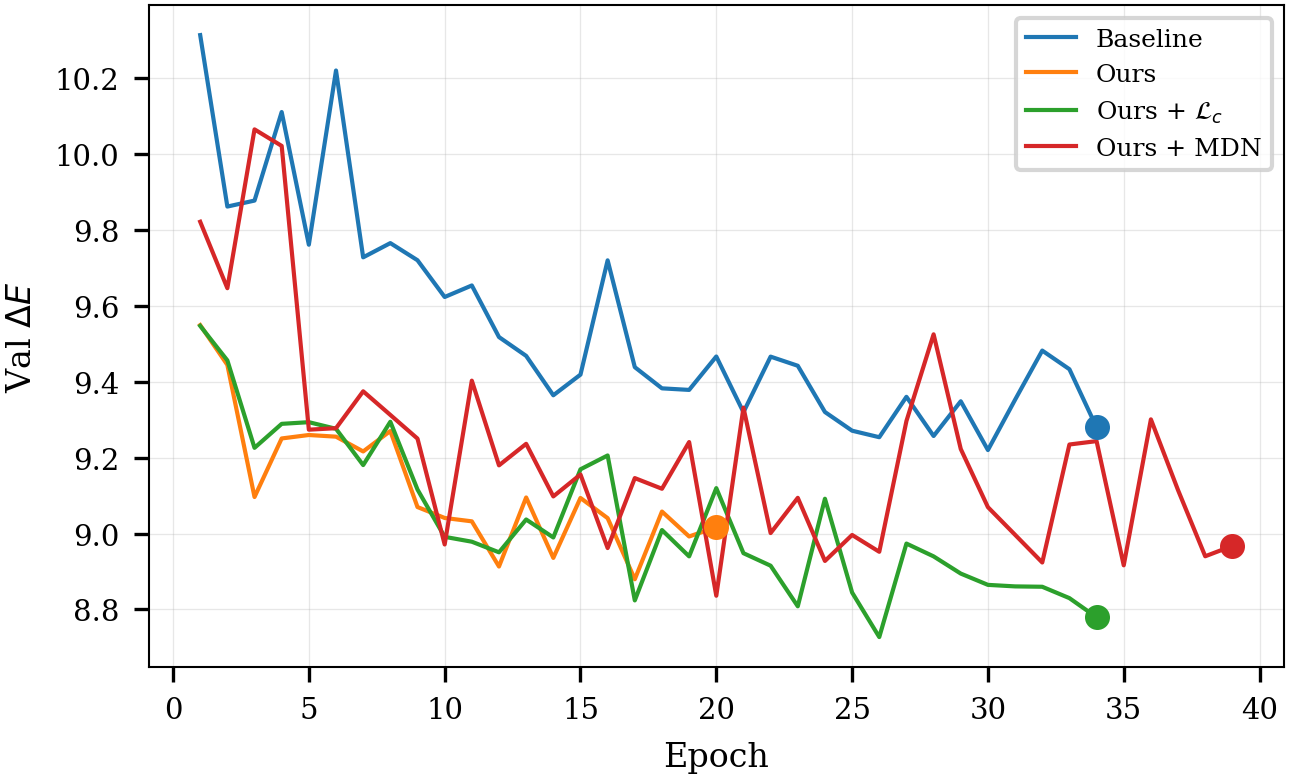

Saved: /content/visuals/fig_5_1_training_deltae.pdf


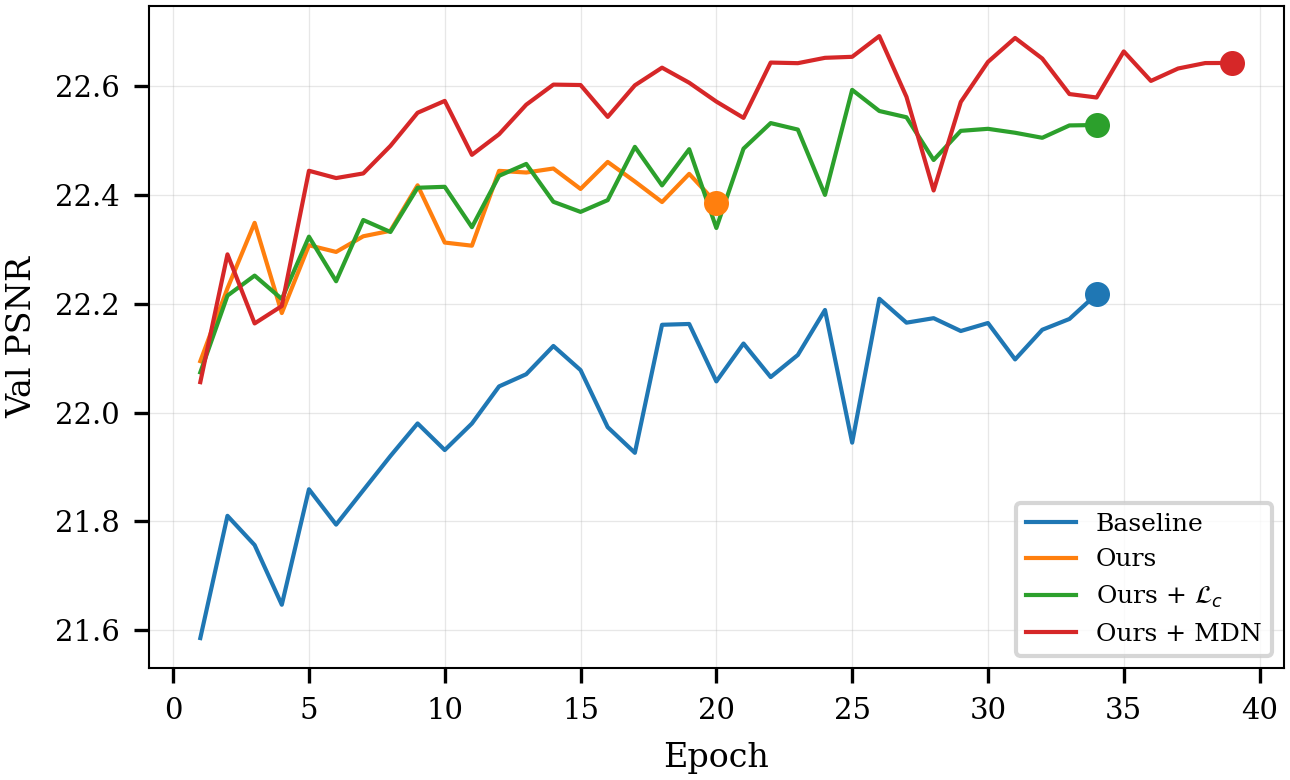

Saved: /content/visuals/fig_5_2_training_psnr.pdf


In [ ]:
hist_map = {
    "Baseline": "baseline",
    "Ours": "ours",
    "Ours + $\\mathcal{L}_c$": "ours_chroma",
    "Ours + MDN": "ours_mdn",
}
colors_map = {"Baseline": "#1f77b4", "Ours": "#ff7f0e",
              "Ours + $\\mathcal{L}_c$": "#2ca02c", "Ours + MDN": "#d62728"}

# Load all history data first
hist_data = {}
for label, dirname in hist_map.items():
    csv_path = os.path.join(RESULTS_DIR, dirname, "metrics_history.csv")
    if not os.path.exists(csv_path):
        print(f"  No history CSV for {dirname}")
        continue
    df_h = pd.read_csv(csv_path)
    if "epoch" not in df_h.columns: continue
    hist_data[label] = df_h

# ── Figure 5-1: Val Delta E ──
if hist_data:
    fig1, ax1 = plt.subplots(1, 1, figsize=(4.5, 2.8))
    for label, df_h in hist_data.items():
        c = colors_map.get(label, None)
        if "val_deltae" in df_h.columns:
            ax1.plot(df_h["epoch"], df_h["val_deltae"], label=label, color=c)
            ax1.scatter(df_h["epoch"].iloc[-1], df_h["val_deltae"].iloc[-1],
                        marker='o', s=25, color=c, zorder=5)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val $\\Delta E$")
    ax1.legend(fontsize=6); ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf_path1 = os.path.join(OUT_DIR, "fig_5_1_training_deltae.pdf")
    fig1.savefig(pdf_path1, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {pdf_path1}")

    # ── Figure 5-2: Val PSNR ──
    fig2, ax2 = plt.subplots(1, 1, figsize=(4.5, 2.8))
    for label, df_h in hist_data.items():
        c = colors_map.get(label, None)
        if "val_psnr" in df_h.columns:
            ax2.plot(df_h["epoch"], df_h["val_psnr"], label=label, color=c)
            ax2.scatter(df_h["epoch"].iloc[-1], df_h["val_psnr"].iloc[-1],
                        marker='o', s=25, color=c, zorder=5)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val PSNR")
    ax2.legend(fontsize=6); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf_path2 = os.path.join(OUT_DIR, "fig_5_2_training_psnr.pdf")
    fig2.savefig(pdf_path2, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {pdf_path2}")
else:
    print("No training history CSVs found -- skipping Figure 5")


In [ ]:
# Show example images with their BLIP captions and extracted tags
N_EXAMPLES = 10
S = CONFIG["img_size"]

sample_caps = test_caps[:N_EXAMPLES] if test_caps else []
if not sample_caps:
    print("No captions available -- skipping caption examples figure")
else:
    n_rows = 2
    n_per_row = 5
    fig, axes = plt.subplots(n_rows, n_per_row, figsize=(2.8*n_per_row, 3.5*n_rows))

    for idx_in_grid, (img_idx, raw_cap, tags) in enumerate(sample_caps[:n_rows*n_per_row]):
        r, c = idx_in_grid // n_per_row, idx_in_grid % n_per_row
        img = Image.open(test_paths[img_idx]).convert("RGB").resize((S, S))

        # Show grayscale (what BLIP sees)
        gray = np.array(img.convert("L"))
        axes[r, c].imshow(gray, cmap="gray")
        axes[r, c].axis("off")

        # Caption below
        wrapped_raw = raw_cap[:45] + ("..." if len(raw_cap) > 45 else "")
        wrapped_tags = tags[:40] + ("..." if len(tags) > 40 else "")
        axes[r, c].text(0.5, -0.04, f"Caption: {wrapped_raw}",
                        transform=axes[r, c].transAxes, ha='center', va='top',
                        fontsize=5.5, color='#333', style='italic')
        axes[r, c].text(0.5, -0.12, f"Tags: {wrapped_tags}",
                        transform=axes[r, c].transAxes, ha='center', va='top',
                        fontsize=5.5, color='#0066cc', weight='bold')

    plt.suptitle("BLIP Captions (from grayscale) and Extracted Object Tags", fontsize=9, y=1.01)
    plt.subplots_adjust(wspace=0.05, hspace=0.25)
    pdf_path = os.path.join(OUT_DIR, "fig_6_caption_examples.pdf")
    fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {pdf_path}")


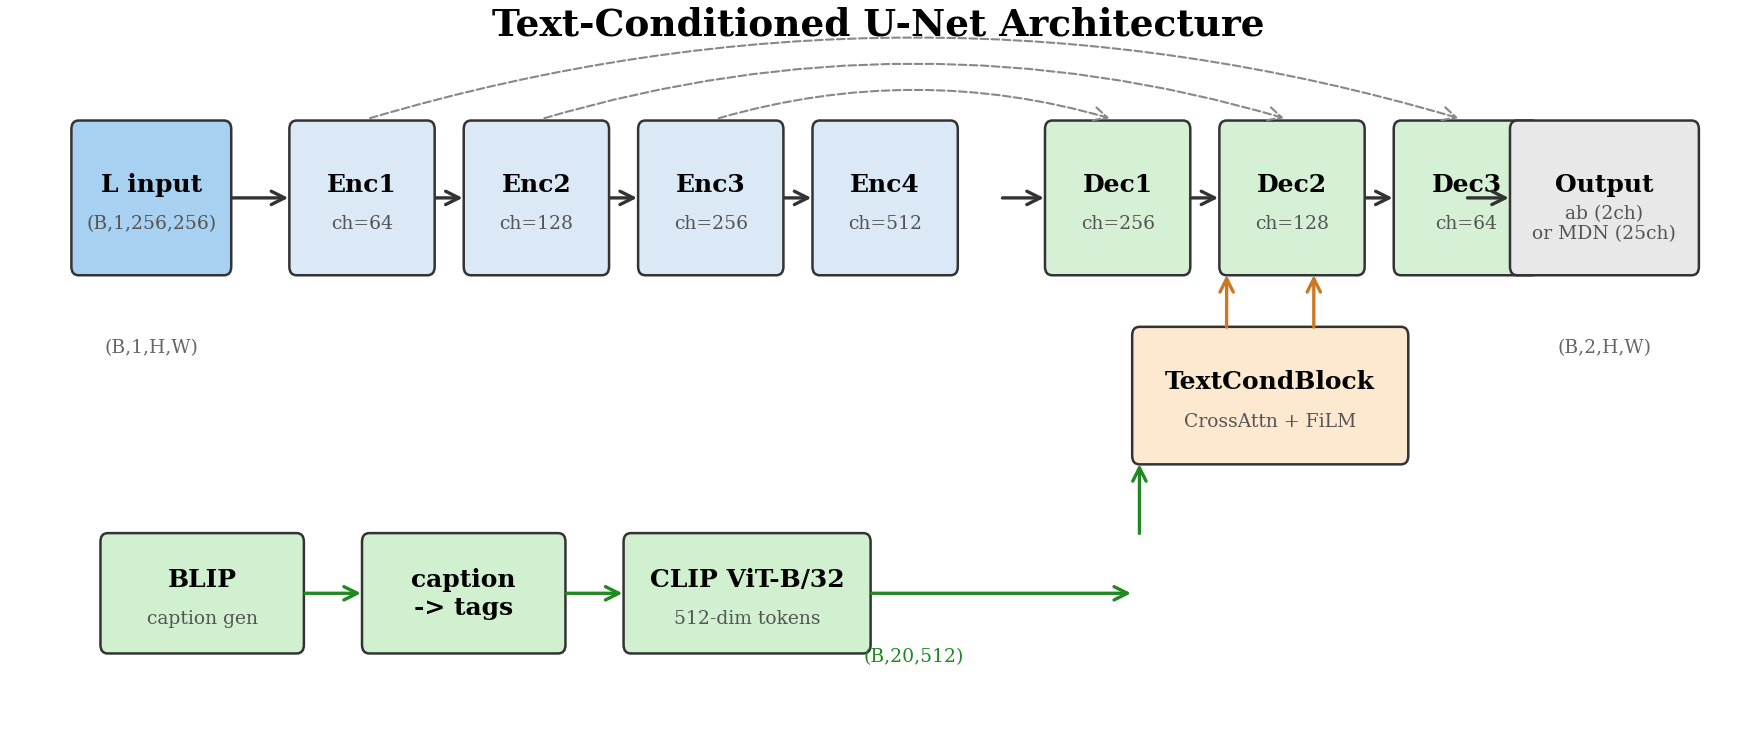

Saved: /content/visuals/fig_1_architecture.pdf


In [ ]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.2))
ax.set_xlim(-0.5, 11.5); ax.set_ylim(-0.5, 3.8); ax.axis('off')

def box(x, y, w, h, label, color='#dbe9f6', fontsize=6, sublabel=None):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                 facecolor=color, edgecolor='#333', linewidth=0.6))
    ax.text(x+w/2, y+h/2+(0.08 if sublabel else 0), label, ha='center', va='center',
            fontsize=fontsize, weight='bold')
    if sublabel:
        ax.text(x+w/2, y+h/2-0.15, sublabel, ha='center', va='center',
                fontsize=4.5, color='#555')

def arrow(x1, y1, x2, y2, color='#333'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

# Image path (blue)
BLUE = '#dbe9f6'; LBLUE = '#a8d0f0'
box(0, 2.3, 1.0, 0.8, 'L input', LBLUE, sublabel='(B,1,256,256)')
arrow(1.0, 2.7, 1.5, 2.7)

# Encoder blocks
enc_labels = [('Enc1','64'), ('Enc2','128'), ('Enc3','256'), ('Enc4','512')]
for i, (name, ch) in enumerate(enc_labels):
    x = 1.5 + i*1.2
    box(x, 2.3, 0.9, 0.8, name, BLUE, sublabel=f'ch={ch}')
    if i < 3: arrow(x+0.9, 2.7, x+1.2, 2.7)

# Arrow to decoder
arrow(6.3, 2.7, 6.7, 2.7)

# Decoder blocks
GREEN = '#d5f0d5'; LGREEN = '#a8e0a8'
dec_labels = [('Dec1','256'), ('Dec2','128'), ('Dec3','64')]
for i, (name, ch) in enumerate(dec_labels):
    x = 6.7 + i*1.2
    box(x, 2.3, 0.9, 0.8, name, GREEN, sublabel=f'ch={ch}')
    if i < 2: arrow(x+0.9, 2.7, x+1.2, 2.7)

# Skip connections
for i in range(3):
    ex = 1.5 + (2-i)*1.2 + 0.45
    dx = 6.7 + i*1.2 + 0.45
    ax.annotate('', xy=(dx, 3.15), xytext=(ex, 3.15),
                arrowprops=dict(arrowstyle='->', color='#888', lw=0.5,
                                connectionstyle='arc3,rad=-0.15', linestyle='dashed'))

# TextConditionedBlock
ORANGE = '#fde8d0'
box(7.3, 1.2, 1.8, 0.7, 'TextCondBlock', ORANGE, fontsize=6,
    sublabel='CrossAttn + FiLM')
arrow(7.9, 1.9, 7.9, 2.3, '#cc7722')
arrow(8.5, 1.9, 8.5, 2.3, '#cc7722')

# Output head
box(9.9, 2.3, 1.2, 0.8, 'Output', '#e8e8e8', sublabel='ab (2ch)\nor MDN (25ch)')
arrow(9.5, 2.7, 9.9, 2.7)

# Text pipeline (green path below)
TGREEN = '#d0f0d0'
box(0.2, 0.1, 1.3, 0.6, 'BLIP', TGREEN, sublabel='caption gen')
arrow(1.5, 0.4, 2.0, 0.4, '#228822')
box(2.0, 0.1, 1.3, 0.6, 'caption\n-> tags', TGREEN, fontsize=6)
arrow(3.3, 0.4, 3.8, 0.4, '#228822')
box(3.8, 0.1, 1.6, 0.6, 'CLIP ViT-B/32', TGREEN, sublabel='512-dim tokens')
arrow(5.4, 0.4, 7.3, 0.4, '#228822')
arrow(7.3, 0.7, 7.3, 1.2, '#228822')

# Shape annotations
ax.text(0.5, 1.8, '(B,1,H,W)', fontsize=4.5, ha='center', color='#666')
ax.text(10.5, 1.8, '(B,2,H,W)', fontsize=4.5, ha='center', color='#666')
ax.text(5.4, 0.0, '(B,20,512)', fontsize=4.5, ha='left', color='#228822')

# Title
ax.text(5.5, 3.65, 'Text-Conditioned U-Net Architecture', ha='center',
        fontsize=9, weight='bold')

pdf_path = os.path.join(OUT_DIR, "fig_1_architecture.pdf")
fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {pdf_path}")


In [ ]:
print("=" * 60)
print("OUTPUTS SUMMARY")
print("=" * 60)
print(f"\nAll files saved to: {OUT_DIR}\n")

import glob as gl
for ext, label in [("*.tex", "TEX tables"), ("*.csv", "CSV data"), ("*.pdf", "PDF figures")]:
    files = sorted(gl.glob(os.path.join(OUT_DIR, ext)))
    if files:
        print(f"  {label}:")
        for f in files:
            size = os.path.getsize(f)
            print(f"    {os.path.basename(f):40s} ({size/1024:.1f} KB)")
        print()

print("Generated files:")
print("  tab_1_main_results.tex")
print("  tab_2_per_category.tex")
print("  tab_3_mdn_decoding.tex")
print("  fig_1_architecture.pdf")
print("  fig_2_qualitative_grid.pdf")
print("  fig_3_chroma_recovery.pdf")
print("  fig_4_mdn_diversity.pdf")
print("  fig_5_1_training_deltae.pdf")
print("  fig_5_2_training_psnr.pdf")
print("  fig_6_caption_examples.pdf")

# ── Copy to Drive ──
import shutil
DRIVE_DST = "/content/drive/MyDrive/visuals"
if os.path.isdir("/content/drive/MyDrive"):
    if os.path.exists(DRIVE_DST):
        shutil.rmtree(DRIVE_DST)
    shutil.copytree(OUT_DIR, DRIVE_DST)
    print(f"\nAll outputs also saved to Drive: {DRIVE_DST}")
else:
    print("\nDrive not available -- outputs only in session storage.")


OUTPUTS SUMMARY

All files saved to: /content/visuals

  TEX tables:
    tab_1_main_results.tex                   (0.8 KB)
    tab_2_per_category.tex                   (0.6 KB)
    tab_3_mdn_decoding.tex                   (0.6 KB)

  CSV data:
    tab_1_main_results.csv                   (0.8 KB)
    tab_2_per_category.csv                   (0.5 KB)
    tab_3_mdn_decoding.csv                   (0.5 KB)

  PDF figures:
    fig_1_architecture.pdf                   (29.4 KB)
    fig_2_qualitative_grid.pdf               (13039.7 KB)
    fig_3_chroma_recovery.pdf                (2460.7 KB)
    fig_4_mdn_diversity.pdf                  (2097.8 KB)
    fig_5_1_training_deltae.pdf              (22.0 KB)
    fig_5_2_training_psnr.pdf                (20.5 KB)
    fig_6_caption_examples.pdf               (2463.9 KB)

Generated files:
  tab_1_main_results.tex
  tab_2_per_category.tex
  tab_3_mdn_decoding.tex
  fig_1_architecture.pdf
  fig_2_qualitative_grid.pdf
  fig_3_chroma_recovery.pdf
  fig_4_m